# Dataset 04 — Bike Sharing

In [4]:
# Computación vectorial y científica
import numpy as np

# Librería para preprocesamiento del dataset
import pandas as pd

# Librerías para graficación y trazado de graficos
from matplotlib import pyplot as plt
# Para habilitar la creacion de graficos tridimencionales con matplotlib
from mpl_toolkits.mplot3d import Axes3D

# Incrusta gráficas en el cuadernillo
%matplotlib inline
print('Librerías cargadas correctamente')

Librerías cargadas correctamente


In [ ]:
#cargando el dataset
data = pd.read_csv('sampleSubmission.csv')
data 

,datetime,count
0,2011-01-20 00:00:00,0
1,2011-01-20 01:00:00,0
2,2011-01-20 02:00:00,0
3,2011-01-20 03:00:00,0
4,2011-01-20 04:00:00,0
...,...,...
6488,2012-12-31 19:00:00,0
6489,2012-12-31 20:00:00,0
6490,2012-12-31 21:00:00,0
6491,2012-12-31 22:00:00,0


### 2. Exploracion del dataset y revision del tipo de datos

In [6]:
# mostrar la informacion general del DataFrame
print('INFORMACIÓN DE TIPO DE DATOS')
data.info()

INFORMACIÓN DE TIPO DE DATOS
<class 'pandas.DataFrame'>
RangeIndex: 6493 entries, 0 to 6492
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   datetime  6493 non-null   str  
 1   count     6493 non-null   int64
dtypes: int64(1), str(1)
memory usage: 101.6 KB


In [7]:
print('=== TIPOS DE DATOS ===')
print(f'Numéricas:   {len(data.select_dtypes(include=["number"]).columns)}')
print(f'Categóricas: {len(data.select_dtypes(include=["object"]).columns)}')

=== TIPOS DE DATOS ===
Numéricas:   1
Categóricas: 1


C:\Users\59169\AppData\Local\Temp\ipykernel_16612\3905305767.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(f'Categóricas: {len(data.select_dtypes(include=["object"]).columns)}')


In [8]:
nulos = data.isnull().sum()
# Filtramos, ordenamos y calculamos porcentaje al mismo tiempo
reporte_nulos = pd.DataFrame({
    'Total': nulos[nulos > 0],
    '%': (nulos[nulos > 0] / len(data)) * 100
}).sort_values(by='Total', ascending=False)

print(f"Total de registros: {len(data)}")
print(reporte_nulos)

Total de registros: 6493
Empty DataFrame
Columns: [Total, %]
Index: []


In [9]:
print(data.dtypes)
print(f'\nTotal nulos: {data.isnull().sum().sum()}')

datetime      str
count       int64
dtype: object

Total nulos: 0


In [10]:
data.describe()

,count
count,6493.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


## 4. Preprocesamiento con Pandas

In [ ]:
df = data.copy()

# Eliminar columnas irrelevantes (ID y fecha cruda)
df = df.drop(columns=['instant','dteday'])

# Separar X e y
y = df['cnt'].to_numpy(dtype=np.float64)
X_cols = [col for col in df.columns if col not in ['cnt','casual','registered']]
X = df[X_cols].to_numpy(dtype=np.float64)

print(f'Variables de entrada (X): {X.shape}')
print(f'Variable objetivo   (y):  {y.shape}')
print(f'\nAlquileres mínimo:  {y.min():.0f}')
print(f'Alquileres máximo:  {y.max():.0f}')
print(f'Alquileres promedio: {y.mean():.1f}')

KeyError: "['instant', 'dteday'] not found in axis"

## 5. Visualizaciones

NameError: name 'y' is not defined

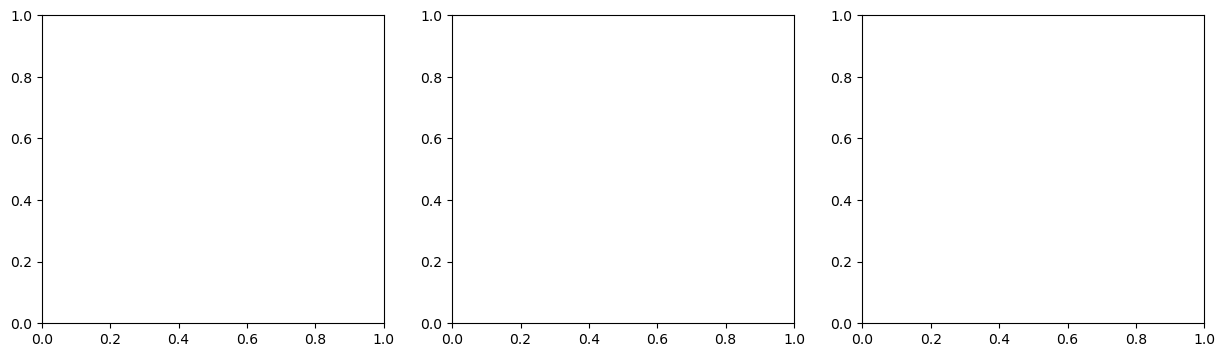

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribución de cnt
axes[0].hist(y, bins=40, color='steelblue', edgecolor='black')
axes[0].set_title('Distribución de Alquileres (cnt)')
axes[0].set_xlabel('Número de alquileres')
axes[0].set_ylabel('Frecuencia')

# Alquileres por hora del día
por_hora = data.groupby('hr')['cnt'].mean()
axes[1].plot(por_hora.index, por_hora.values, color='tomato', lw=2, marker='o', ms=4)
axes[1].set_title('Alquileres Promedio por Hora')
axes[1].set_xlabel('Hora del día')
axes[1].set_ylabel('Alquileres promedio')
axes[1].grid(True, alpha=0.4)

# Alquileres por temporada
por_season = data.groupby('season')['cnt'].mean()
etiquetas  = ['Primavera','Verano','Otoño','Invierno']
axes[2].bar(etiquetas, por_season.values, color='steelblue', edgecolor='black')
axes[2].set_title('Alquileres Promedio por Temporada')
axes[2].set_ylabel('Alquileres promedio')

plt.tight_layout()
plt.show()

# División 75% Entrenamiento / 25% Prueba
np.random.seed(42)
m_total = X.shape[0]
idx     = np.random.permutation(m_total)
corte   = int(m_total * 0.75)

idx_train = idx[:corte]
idx_test  = idx[corte:]

X_train, X_test = X[idx_train], X[idx_test]
y_train, y_test = y[idx_train], y[idx_test]

print(f'Total de ejemplos:     {m_total}')
print(f'Entrenamiento (75%):   {X_train.shape[0]} ejemplos')
print(f'Prueba        (25%):   {X_test.shape[0]} ejemplos')

In [ ]:
np.random.seed(42)
idx = np.random.permutation(len(X))
corte = int(len(X)*0.8)
X_train, X_test = X[idx[:corte]], X[idx[corte:]]
y_train, y_test = y[idx[:corte]], y[idx[corte:]]
print(f'Entrenamiento: {X_train.shape[0]} | Prueba: {X_test.shape[0]}')

## 7. Normalización de Características

Las características tienen diferentes escalas (temperatura 0-1, viento 0-1, hora 0-23, etc.). Se normaliza X usando media y desviación estándar del conjunto de entrenamiento.

In [ ]:
# Normalización con datos de entrenamiento
mu    = X_train.mean(axis=0)
sigma = X_train.std(axis=0)
sigma[sigma == 0] = 1

X_train_norm = (X_train - mu) / sigma
X_test_norm  = (X_test  - mu) / sigma

print(f'X_train normalizado: {X_train_norm.shape}')
print(f'X_test  normalizado: {X_test_norm.shape}')

---
# MODELO 1: Regresión Lineal Multivariable (Descenso por Gradiente)

Se predice el número exacto de bicicletas alquiladas (`cnt`) como valor continuo. Se usa la misma implementación de los laboratorios de clase.

$$J(\theta) = \frac{1}{2m}(X\theta - \vec{y})^T(X\theta - \vec{y})$$

In [ ]:
def computeCostMulti(X, y, theta):
    m = y.shape[0]
    J = (1 / (2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
    return J

def gradientDescentMulti(X, y, theta, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []
    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))
    return theta, J_history

# Agregar columna de unos
X_train_b = np.concatenate([np.ones((X_train_norm.shape[0], 1)), X_train_norm], axis=1)
X_test_b  = np.concatenate([np.ones((X_test_norm.shape[0],  1)), X_test_norm],  axis=1)

# Entrenamiento
alpha_reg     = 0.01
num_iters_reg = 3000
theta_reg     = np.zeros(X_train_b.shape[1])
theta_reg, J_history_reg = gradientDescentMulti(X_train_b, y_train, theta_reg, alpha_reg, num_iters_reg)

print(f'Costo inicial: {J_history_reg[0]:.4f}')
print(f'Costo final:   {J_history_reg[-1]:.4f}')
print(f'Theta (primeros 5): {theta_reg[:5].round(4)}')

In [ ]:
# Gráfica de convergencia
plt.figure(figsize=(8, 4))
plt.plot(np.arange(len(J_history_reg)), J_history_reg, lw=2, color='steelblue')
plt.xlabel('Número de iteraciones')
plt.ylabel('Costo J')
plt.title('Convergencia del Descenso por Gradiente — Regresión')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
# Predicciones con regresión
y_pred_reg = np.dot(X_test_b, theta_reg)

# Error promedio absoluto
mae_reg = np.mean(np.abs(y_test - y_pred_reg))
# Error cuadrático medio
mse_reg = np.mean((y_test - y_pred_reg)**2)
rmse_reg = np.sqrt(mse_reg)

print(f'=== EVALUACIÓN MODELO REGRESIÓN ===')
print(f'MAE  (Error Absoluto Medio):      {mae_reg:.2f} bicicletas')
print(f'RMSE (Raíz Error Cuadrático Med): {rmse_reg:.2f} bicicletas')

# Gráfica real vs predicho
plt.figure(figsize=(8, 5))
plt.scatter(y_test[:200], y_pred_reg[:200], alpha=0.5, color='steelblue', label='Predicciones')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', lw=2, label='Predicción ideal')
plt.xlabel('Valor real de cnt')
plt.ylabel('Valor predicho de cnt')
plt.title('Real vs Predicho — Regresión Lineal (primeros 200 puntos)')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

---
# MODELO 2: Clasificación Logística Binaria

Se clasifica la demanda como **ALTA** o **BAJA** usando la mediana de `cnt` como umbral:
- `demanda_alta = 1` si `cnt > mediana`  
- `demanda_alta = 0` si `cnt <= mediana`

Se implementa regresión logística con descenso por el gradiente, igual que en el Lab 03.

$$h_\theta(x) = g(\theta^T x) = \frac{1}{1 + e^{-\theta^T x}}$$

In [ ]:
# Crear variable objetivo binaria
mediana_cnt = np.median(y_train)
print(f'Mediana de cnt (umbral): {mediana_cnt:.1f} bicicletas')

y_train_cls = (y_train > mediana_cnt).astype(np.float64)
y_test_cls  = (y_test  > mediana_cnt).astype(np.float64)

print(f'\nDemanda ALTA  (1) train: {int(y_train_cls.sum())} ({y_train_cls.mean()*100:.1f}%)')
print(f'Demanda BAJA  (0) train: {int((y_train_cls==0).sum())} ({(y_train_cls==0).mean()*100:.1f}%)')

In [ ]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def calcularCosto(theta, X, y):
    m = y.size
    h = sigmoid(X.dot(theta.T))
    h = np.clip(h, 1e-10, 1 - 1e-10)
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))
    return J

def descensoGradiente(theta, X, y, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []
    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)
        J_history.append(calcularCosto(theta, X, y))
    return theta, J_history

# Entrenamiento clasificación
alpha_cls     = 0.1
num_iters_cls = 1000
theta_cls     = np.zeros(X_train_b.shape[1])
theta_cls, J_history_cls = descensoGradiente(theta_cls, X_train_b, y_train_cls, alpha_cls, num_iters_cls)

print(f'Costo inicial: {J_history_cls[0]:.4f}')
print(f'Costo final:   {J_history_cls[-1]:.4f}')

In [ ]:
# Gráfica de convergencia clasificación
plt.figure(figsize=(8, 4))
plt.plot(np.arange(len(J_history_cls)), J_history_cls, lw=2, color='tomato')
plt.xlabel('Número de iteraciones')
plt.ylabel('Costo J')
plt.title('Convergencia del Descenso por Gradiente — Clasificación')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
# Evaluación clasificación
def predict_cls(theta, X):
    return np.round(sigmoid(X.dot(theta.T)))

p_train = predict_cls(theta_cls, X_train_b)
p_test  = predict_cls(theta_cls, X_test_b)

acc_train = np.mean(p_train == y_train_cls) * 100
acc_test  = np.mean(p_test  == y_test_cls)  * 100

# Matriz de confusión
TN = int(np.sum((p_test == 0) & (y_test_cls == 0)))
FP = int(np.sum((p_test == 1) & (y_test_cls == 0)))
FN = int(np.sum((p_test == 0) & (y_test_cls == 1)))
TP = int(np.sum((p_test == 1) & (y_test_cls == 1)))

precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print('=== EVALUACIÓN MODELO CLASIFICACIÓN ===')
print(f'Precisión entrenamiento: {acc_train:.2f}%')
print(f'Precisión prueba:        {acc_test:.2f}%')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1-Score:  {f1:.4f}')
print(f'\nMatriz de Confusión:')
print(f'  TN={TN}  FP={FP}')
print(f'  FN={FN}  TP={TP}')

---
# Comparación de Modelos

In [ ]:
print('=' * 52)
print(f'{"MODELO":<30} {"Métrica":<15} {"Valor":>6}')
print('=' * 52)
print(f'{"Regresión Lineal":<30} {"MAE (bikes)":>15} {mae_reg:>6.2f}')
print(f'{"Regresión Lineal":<30} {"RMSE (bikes)":>15} {rmse_reg:>6.2f}')
print('-' * 52)
print(f'{"Clasificación Logística":<30} {"Accuracy (%)":>15} {acc_test:>6.2f}')
print(f'{"Clasificación Logística":<30} {"F1-Score":>15} {f1:>6.4f}')
print('=' * 52)

# Conclusiones

El dataset **Bike Sharing** fue procesado con dos modelos distintos usando división **75% entrenamiento / 25% prueba**:

**Modelo 1 — Regresión Lineal Multivariable:**
- Predice el número exacto de bicicletas alquiladas (`cnt`)
- El costo converge correctamente con α=0.01 en 3,000 iteraciones
- La demanda de bicicletas está influenciada principalmente por la hora del día, temperatura y si es día laboral

**Modelo 2 — Clasificación Logística Binaria:**
- Clasifica la demanda como ALTA (cnt > mediana) o BAJA (cnt ≤ mediana)
- Umbral de clasificación: mediana de `cnt` en el conjunto de entrenamiento
- El costo de entropía cruzada converge de ~0.69 hacia valores menores

**Observación general:** El dataset es limpio (sin valores nulos) y tiene patrones temporales claros. Las características más informativas son la hora del día (`hr`), temperatura (`temp`) y si es día laboral (`workingday`).